cifar dataset comprises of 10 classes of images with integer labels and 60000 images of  32 × 32 pixels
3 color channels (RGB)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 45ms/step - accuracy: 0.4426 - loss: 1.5276
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.5942 - loss: 1.1451
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.6504 - loss: 0.9942
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.6862 - loss: 0.8935
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 44ms/step - accuracy: 0.7106 - loss: 0.8250
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7287 - loss: 0.7721
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 39ms/step - accuracy: 0.7467 - loss: 0.7210
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 42ms/step - accuracy: 0.7641 - loss: 0.6768
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.7784 - loss: 0.6325
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7909 - loss: 0.5965
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7097 - loss: 0.8545
313/313 ━━━━━━━━━━━━━━━

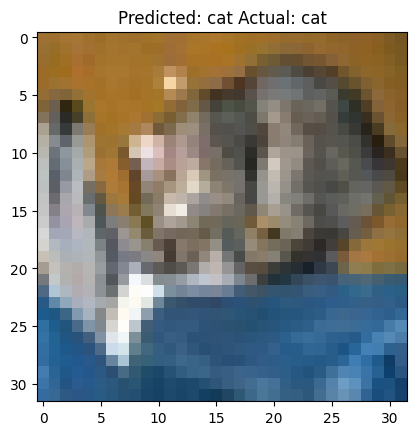

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 dataset
cifar = keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Build CNN model
model = keras.Sequential([

    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),

    keras.layers.Flatten(),

    keras.layers.Dense(64,activation='relu'),

    keras.layers.Dense(10,activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(X_train,y_train,epochs=10)

# Evaluate model
model.evaluate(X_test,y_test)

# Predict
predictions = model.predict(X_test)

# Show image
plt.imshow(X_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])] +
          " Actual: " + class_names[y_test[0][0]])
plt.show()